1. Criar API token no kaggle
2. mkdir -p ~/.kaggle
3. Criar arquivo kaggle.json na pasta .kaggle
4. Escrever em kaggle.json {"username":"seu_usuario","key":"123456789abcde..."}
5. chmod 600 ~/.kaggle/kaggle.json
6. Reiniciar o kernel


In [1]:
import torch
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import random
from torch.utils.data import Subset
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import time
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
import torchvision.transforms as transforms
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import copy

In [2]:
def set_seed(seed=42):
    """
    Congela a aleatoriedade de todas as bibliotecas para garantir a reprodutibilidade.
    """
    # 1. Congela o Python nativo
    random.seed(seed)
    
    # 2. Congela o NumPy 
    np.random.seed(seed)
    
    # 3. Congela o PyTorch (CPU)
    torch.manual_seed(seed)
    
    # 4. Congela o PyTorch (GPU/CUDA) 
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) 
        
        # Força o cuDNN a ser determinístico (pode deixar o treino levemente mais lento, mas é 100% reproduzível)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Chamamos a função passando um número arbitrário (42 é a tradição na comunidade de ML)
set_seed(42)

In [3]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('histopathologic-cancer-detection')

print("Path to competition files:", path)

c:\UNICAMP\7_Semestre\MC906-Histopathologic-Cancer-Detection\mc906_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to competition files: C:\Users\ferna\.cache\kagglehub\competitions\histopathologic-cancer-detection


In [4]:
pastas_baixadas = os.listdir(path)
print("Conteúdo da pasta raiz:", pastas_baixadas)

Conteúdo da pasta raiz: ['sample_submission.csv', 'test', 'train', 'train_labels.csv']


In [5]:
# 1. CRIANDO A CLASSE DO DATASET CUSTOMIZADO
class HistopathologicDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        """
        dataframe: Pandas DataFrame contendo as colunas 'id' e 'label'
        img_dir: Caminho para a pasta contendo as imagens
        transform: Transformações do torchvision.transforms
        """
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # O Kaggle fornece os IDs sem a extensão, então adicionamos '.tif'
        img_name = self.dataframe.iloc[idx, 0] + '.tif'
        img_path = os.path.join(self.img_dir, img_name)
        
        # Abre a imagem e converte para RGB (caso haja alguma em escala de cinza/RGBA)
        image = Image.open(img_path).convert('RGB')
        
        # Pega o rótulo da imagem (0 ou 1)
        label = int(self.dataframe.iloc[idx, 1])
        
        if self.transform:
            image = self.transform(image)
            
        return image, label


# Tamanhos definidos
CROP_SIZE = 64  # Mantém o centro seguro e descarta as bordas distantes

# Médias e Desvios Padrões do dataset ImageNet
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Pipeline de TREINO (Leve e rápido)
train_transforms = transforms.Compose([
    transforms.CenterCrop(CROP_SIZE),        # Recorta para 64x64
    transforms.RandomHorizontalFlip(p=0.5),  # Data Augmentation
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=90),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),                   # Converte para Tensor
    transforms.Normalize(mean, std)          # Normaliza
])

# Pipeline de VALIDAÇÃO e TESTE (Leve e limpo)
test_val_transforms = transforms.Compose([
    transforms.CenterCrop(CROP_SIZE),        # Recorta para 64x64
    transforms.ToTensor(),                   # Converte para Tensor
    transforms.Normalize(mean, std)          # Normaliza
])

# 3. CARREGANDO E DIVIDINDO OS DADOS COM PANDAS
data_dir = path
train_dir = os.path.join(data_dir, 'train')
csv_path = os.path.join(data_dir, 'train_labels.csv')

# Lê o CSV com os IDs e os labels
df = pd.read_csv(csv_path)

# Usamos o scikit-learn para dividir o DataFrame (90% treino, 10% validação)
# O parâmetro 'stratify' garante que a proporção de câncer/não-câncer seja mantida na validação
df_train, df_val = train_test_split(df, test_size=0.10, random_state=42, stratify=df['label'])

# Resetar os índices para evitar problemas no DataLoader
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

# 4. INSTANCIANDO OS DATASETS CUSTOMIZADOS
train_dataset = HistopathologicDataset(dataframe=df_train, img_dir=train_dir, transform=train_transforms)
val_dataset = HistopathologicDataset(dataframe=df_val, img_dir=train_dir, transform=test_val_transforms)

# 5. CONFIGURANDO OS DATALOADERS
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f"Total de imagens no CSV: {len(df)}")
print(f"Treino: {len(train_dataset)} | Validação: {len(val_dataset)}")

Total de imagens no CSV: 220025
Treino: 198022 | Validação: 22003


1. Iniciando a extração do lote...
2. Lote extraído com sucesso! Shape das imagens: torch.Size([64, 3, 64, 64])
3. Gerando o grid de imagens...
4. Plotando o gráfico...


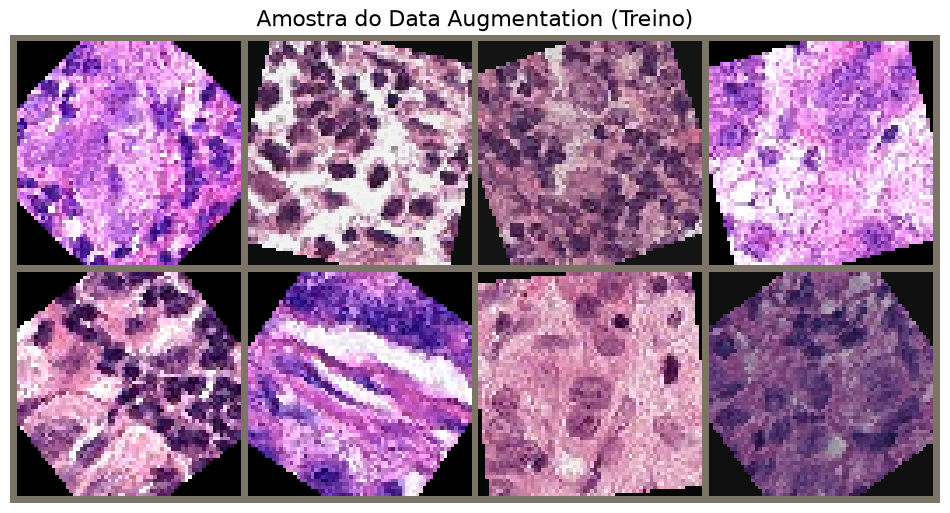

In [6]:
def visualizar_batch(dataloader, num_imagens=8):
    print("1. Iniciando a extração do lote...")
    try:
        # A linha onde o Windows costuma travar
        images, labels = next(iter(dataloader))
        print(f"2. Lote extraído com sucesso! Shape das imagens: {images.shape}")
    except Exception as e:
        print(f"Erro ao extrair lote: {e}")
        return
    
    images = images[:num_imagens]
    labels = labels[:num_imagens]
    
    print("3. Gerando o grid de imagens...")
    grid = torchvision.utils.make_grid(images, nrow=4, padding=2)
    
    np_grid = grid.numpy()
    np_grid = np.transpose(np_grid, (1, 2, 0))
    
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    np_grid = std * np_grid + mean
    np_grid = np.clip(np_grid, 0, 1)
    
    print("4. Plotando o gráfico...")
    plt.figure(figsize=(12, 12))
    plt.imshow(np_grid)
    plt.axis('off')
    plt.title('Amostra do Data Augmentation (Treino)', fontsize=16)
    plt.show()

# Testando com o DataLoader à prova de balas
if __name__ == "__main__":
    visualizar_batch(train_loader)

In [7]:
# Arquitetura da CNN

class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))
        
        x = torch.flatten(x, 1)
        
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# --- INSTANCIAÇÃO E CONFIGURAÇÃO ---

# Detecta se há uma GPU disponível
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Utilizando dispositivo: {device}")

# Cria o modelo e o envia para a GPU/CPU
model = BaselineCNN().to(device)

# Função de Perda: Binary Cross Entropy with Logits
# Esta função é mais numericamente estável do que aplicar um Sigmoid na rede e usar BCELoss.
criterion = nn.BCEWithLogitsLoss()

# Otimizador Adam com taxa de aprendizado padrão
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Teste rápido de Sanidade (Sanity Check)
# Cria um tensor falso com o mesmo formato de um batch nosso para ver se a rede compila
dummy_input = torch.randn(64, 3, 64, 64).to(device)
dummy_output = model(dummy_input)
print(f"Formato da saída do modelo: {dummy_output.shape} (Esperado: [64, 1])")

Utilizando dispositivo: cuda
Formato da saída do modelo: torch.Size([64, 1]) (Esperado: [64, 1])


In [8]:
def treinar_modelo(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10):
    """
    Função genérica para treinar e validar modelos PyTorch.
    Retorna o modelo treinado e um dicionário contendo o histórico de métricas.
    """
    
    historico = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'val_auc': []
    }

    print(f"Iniciando o treinamento no dispositivo: {device}")

    for epoch in range(num_epochs):
        # ==========================================
        #               FASE DE TREINO
        # ==========================================
        model.train()
        
        train_loss_acumulada = 0.0
        train_corretos = 0
        train_total = 0
        
        loop_treino = tqdm(train_loader, desc=f'Época {epoch+1}/{num_epochs} [Treino]', leave=False)
        
        for images, labels in loop_treino:
            images = images.to(device)
            labels = labels.to(device).float().unsqueeze(1)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            train_loss_acumulada += loss.item() * images.size(0)
            
            probabilidades = torch.sigmoid(outputs)
            previsoes = (probabilidades >= 0.5).float()
            
            train_corretos += (previsoes == labels).sum().item()
            train_total += labels.size(0)
            
            loop_treino.set_postfix(loss=loss.item())

        epoca_train_loss = train_loss_acumulada / train_total
        epoca_train_acc = train_corretos / train_total
        
        historico['train_loss'].append(epoca_train_loss)
        historico['train_acc'].append(epoca_train_acc)

        # ==========================================
        #              FASE DE VALIDAÇÃO
        # ==========================================
        model.eval()
        
        val_loss_acumulada = 0.0
        val_corretos = 0
        val_total = 0
        
        todas_probabilidades_val = []
        todos_labels_val = []
        
        with torch.no_grad():
            loop_val = tqdm(val_loader, desc=f'Época {epoch+1}/{num_epochs} [Validação]', leave=False)
            for images, labels in loop_val:
                images = images.to(device)
                labels = labels.to(device).float().unsqueeze(1)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss_acumulada += loss.item() * images.size(0)
                
                probabilidades = torch.sigmoid(outputs)
                previsoes = (probabilidades >= 0.5).float()
                
                val_corretos += (previsoes == labels).sum().item()
                val_total += labels.size(0)
                
                todas_probabilidades_val.extend(probabilidades.cpu().numpy())
                todos_labels_val.extend(labels.cpu().numpy())

        epoca_val_loss = val_loss_acumulada / val_total
        epoca_val_acc = val_corretos / val_total
        epoca_val_auc = roc_auc_score(todos_labels_val, todas_probabilidades_val)
        
        historico['val_loss'].append(epoca_val_loss)
        historico['val_acc'].append(epoca_val_acc)
        historico['val_auc'].append(epoca_val_auc)

        # ==========================================
        #               RELATÓRIO DA ÉPOCA
        # ==========================================
        print(f"Época {epoch+1:02d}/{num_epochs} | "
              f"Train Loss: {epoca_train_loss:.4f} | Train Acc: {epoca_train_acc:.4f} || "
              f"Val Loss: {epoca_val_loss:.4f} | Val Acc: {epoca_val_acc:.4f} | Val AUC: {epoca_val_auc:.4f}")

    print("Treinamento concluído!")
    
    # NOVA LINHA: Retornando o modelo e o histórico
    return model, historico

# ==========================================
#     EXECUTANDO O TREINAMENTO DO MODELO
# ==========================================

# Capturando tanto o modelo treinado quanto o histórico
modelo_baseline_treinado, historico_baseline = treinar_modelo(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=10
)

Iniciando o treinamento no dispositivo: cuda


Época 01/10 | Train Loss: 0.4187 | Train Acc: 0.8136 || Val Loss: 0.3432 | Val Acc: 0.8562 | Val AUC: 0.9258


Época 02/10 | Train Loss: 0.3442 | Train Acc: 0.8536 || Val Loss: 0.3477 | Val Acc: 0.8513 | Val AUC: 0.9419


Época 03/10 | Train Loss: 0.3254 | Train Acc: 0.8627 || Val Loss: 0.3771 | Val Acc: 0.8405 | Val AUC: 0.9326


Época 04/10 | Train Loss: 0.3134 | Train Acc: 0.8686 || Val Loss: 0.2855 | Val Acc: 0.8818 | Val AUC: 0.9479


...

Época 06/10 | Train Loss: 0.2990 | Train Acc: 0.8771 || Val Loss: 0.2673 | Val Acc: 0.8912 | Val AUC: 0.9526


Época 07/10 | Train Loss: 0.2950 | Train Acc: 0.8783 || Val Loss: 0.2585 | Val Acc: 0.8956 | Val AUC: 0.9561


Época 08/10 | Train Loss: 0.2905 | Train Acc: 0.8811 || Val Loss: 0.2951 | Val Acc: 0.8782 | Val AUC: 0.9530


Época 09/10 | Train Loss: 0.2881 | Train Acc: 0.8825 || Val Loss: 0.2971 | Val Acc: 0.8730 | Val AUC: 0.9542


Época 10/10 | Train Loss: 0.2855 | Train Acc: 0.8840 || Val Loss: 0.2474 | Val Acc: 0.8985 | Val AUC: 0.9604
Treinamento concluído!


In [9]:
import torch
print("Versão do PyTorch:", torch.__version__)

Versão do PyTorch: 2.5.1+cu121


In [1]:
def avaliar_modelo(model, dataloader, criterion, device):
    """
    Avalia o modelo em um dataloader específico (validação ou teste),
    calcula métricas chave e plota a Matriz de Confusão e a Curva ROC.
    """
    print("Iniciando avaliação...")
    model.eval() # Modo de avaliação (desativa dropout e batchnorm)
    
    loss_acumulada = 0.0
    
    # Listas para guardar resultados
    todas_probabilidades = []
    todas_previsoes = []
    todos_labels = []
    
    with torch.no_grad(): # Desativa o cálculo de gradientes
        loop_aval = tqdm(dataloader, desc='Avaliando', leave=False)
        for images, labels in loop_aval:
            images = images.to(device)
            labels = labels.to(device).float().unsqueeze(1)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            loss_acumulada += loss.item() * images.size(0)
            
            # Aplica Sigmoid para obter probabilidades entre 0 e 1
            probs = torch.sigmoid(outputs).cpu().numpy()
            
            # Threshold de 0.5 para prever a classe final
            preds = (probs >= 0.5).astype(float)
            
            todas_probabilidades.extend(probs)
            todas_previsoes.extend(preds)
            todos_labels.extend(labels.cpu().numpy())

    # Formata as listas para arrays do NumPy (1D)
    todos_labels = np.array(todos_labels).flatten()
    todas_probabilidades = np.array(todas_probabilidades).flatten()
    todas_previsoes = np.array(todas_previsoes).flatten()
    
    # Cálculos das Métricas
    loss_media = loss_acumulada / len(todos_labels)
    acuracia = accuracy_score(todos_labels, todas_previsoes)
    roc_auc = roc_auc_score(todos_labels, todas_probabilidades)
    
    print("\n" + "="*40)
    print("🩺 RESULTADOS DA AVALIAÇÃO")
    print("="*40)
    print(f"Loss Média: {loss_media:.4f}")
    print(f"Acurácia:   {acuracia:.4f} ({acuracia*100:.2f}%)")
    print(f"ROC-AUC:    {roc_auc:.4f}")
    print("="*40)
    
    # ==========================================
    #               PLOTS E GRÁFICOS
    # ==========================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Matriz de Confusão
    cm = confusion_matrix(todos_labels, todas_previsoes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
                xticklabels=['Normal (0)', 'Tumor (1)'], 
                yticklabels=['Normal (0)', 'Tumor (1)'])
    axes[0].set_title('Matriz de Confusão', fontsize=14)
    axes[0].set_xlabel('Previsão do Modelo', fontsize=12)
    axes[0].set_ylabel('Rótulo Verdadeiro (Ground Truth)', fontsize=12)
    
    # 2. Curva ROC
    fpr, tpr, thresholds = roc_curve(todos_labels, todas_probabilidades)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (área = {roc_auc:.4f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Linha de aleatoriedade
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
    axes[1].set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
    axes[1].set_title('Característica de Operação do Receptor (ROC)', fontsize=14)
    axes[1].legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()

    # Retorna as métricas caso queira salvá-las em variáveis
    return {'loss': loss_media, 'accuracy': acuracia, 'roc_auc': roc_auc}

In [ ]:
# Avaliando o modelo na base de validação
metricas_validacao = avaliar_modelo(
    model=modelo_baseline_treinado, 
    dataloader=val_loader, 
    criterion=criterion, 
    device=device
)